In [4]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch import tensor as tt

import sys as sys
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
import netCDF4 as nc


In [5]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

def revert_to_indep_gauss(dependent_samples, chol_cov):
    return dependent_samples @ torch.linalg.inv(chol_cov).T

norm = torch.distributions.Normal(0.0, 1.0)


In [6]:
#################################################################### Loading GNM ####################################################################
sys.path.append('../')

import pickle


GNM_output = pickle.load( open("trainset_output_1999-07_2019-07.pkl","rb") )
#################################################################### Problematic locations? ###############################################################

location_keys = list(GNM_output.keys())                 # '([0, 16], [44, 60])', ...
output_keys = list(GNM_output[location_keys[0]].keys()) # 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'date', 5'pred_p', 6'mask', 7'idx_loc_in_region'

# May have to remove a location that doesn't have the correct number of days:
location_keys.remove(location_keys[344]) #to remove for gamma_20_20 from 1999-2019 
#location_keys.remove(location_keys[336]) #to remove for gamma_20_20 from 1979-1999
#################################################################### Utility functions ####################################################################
def give_lat_lon(location_key):
    return [ int(re.findall(r'\d+',string)[0]) for string in location_key.split(',')]

def is_loc_land(location,row,column):
    return GNM_output[location]['mask'][0][row][column]

#location_keys.remove('lat_50.95_49.35_lon_-4.55_-2.95') # 'lat_50.95_49.35_lon_-4.55_-2.95' has no data after week indexed 255, so I did not consider it.
day_dates = [pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date']]
output_keys.remove('idx_loc_in_region') # not usefull
output_keys.remove('date') # no more usefull

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

GNM_landonly = [] 
land_counter = -1
for location in tqdm(location_keys):
    for col in range(4):
        for row in range(4):
            if not is_loc_land(location,row,col):#check if land
               continue  
            land_counter+=1
            GNM_landonly.append([[],[],[],[],[]]) # parameters except location
            temp_lat_lon = give_lat_lon(location)
            GNM_landonly[land_counter].append([temp_lat_lon[1]-8+row,(temp_lat_lon[2])+6+col]) #location
            for param_idx,param in enumerate(output_keys[:-1]):
                for day in range(len(GNM_output[location_keys[0]]['pred_mu'])):
                    qqq = [location,param,day,row,col]
                    GNM_landonly[land_counter][param_idx].append(GNM_output[location][param][day][row,col])

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))

#################################################################### Elevation data ####################################################################
fn = 'topo_0.1_degree.nc'
ds = nc.Dataset(fn)
h = ds['Band1'][:]
h = np.flip(np.matrix(h),axis=0)

# load obs_norm_all and censor_levels_di
obs_norm_all = np.load('obs_norm_all_trainCdf_1999_2019.npy')
obs_norm_all = tt(obs_norm_all)
censor_levels_di = np.load('censor_levels_di_trainCdf_1999_2019.npy')
censor_levels_di = tt(censor_levels_di)
censor_levels_u = scs.norm.cdf(censor_levels_di)

100%|██████████| 344/344 [01:16<00:00,  4.48it/s]


In [7]:
def sample_uncensored_copula(alpha,theta,n_sims,GNM_landonly,fixed_noise=None, return_dist_matrix=False, return_cov_matrix=False):
    ''' 
    Sample from a Gaussian copula model.

    Parameters:
        alpha: float, elevation parameter
        theta: float, Matern parameter
        n_sims: int, number of simulations per day
        GNM_landonly: list, list of location data from marginal model
        fixed_noise: tensor, fixed noise for sampling
        return_dist_matrix: bool, return distance matrix
        return_cov_matrix: bool, return covariance matrix
    '''
    if fixed_noise==None: # have to generate my own noise
        fixed_noise = torch.randn(n_sims,len(GNM_landonly), dtype=torch.float64)
    # distance matrix
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
    alpha*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
    estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # covariance matrix
    estimated_cov_matrix = torch_Matern_05(estimated_dist_matrix, theta)
    # sampling with Cholesky decomposition
    sim_z_est = sample_Gauss_fixed_noise(fixed_noise, torch.linalg.cholesky(estimated_cov_matrix)).to(dtype=torch.float16)

    out = [sim_z_est]
    if return_dist_matrix:
        out.append(estimated_dist_matrix)
    if return_cov_matrix:
        out.append(estimated_cov_matrix)
    return tuple(out)

# Example
#sims = sample_censored_copula(alpha=0,theta=34.8212,n_sims_per_day=10,censor_levels=censor_levels_di[:2],fixed_noise=None, return_dist_matrix=True, return_cov_matrix=True)


def plot_samples(samples, GNM_landonly, vmin=None, vmax=None):
    """
    Plot a series of scatter plots for the given samples.

    Parameters:
        samples (torch.Tensor): Input samples of shape (n, 4087).
        GNM_landonly (list): List of location data.
        vmin (float): Minimum value for color scale.
        vmax (float): Maximum value for color scale.
    """
    n = samples.shape[0]

    # Check if samples is a torch tensor and requires gradients
    if isinstance(samples, torch.Tensor):
        samples = samples.detach().numpy()

    
    for i in range(n):
        fig, ax = plt.subplots(figsize=(14,8))
        
        if vmin is None or vmax is None:
            vmin_ = samples[i].min().item()
            vmax_ = samples[i].max().item()
        
        sc = ax.scatter(
            [GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
            c=samples[i], cmap='inferno_r', vmin=vmin_, vmax=vmax_, s=20,marker='s'
        )
        
        ax.set_title(f'Sample {i} Scatter Plot')
        fig.colorbar(sc, ax=ax)
        plt.show()

# Example
# plot_samples(sims[0][0,0,:].unsqueeze(0), GNM_landonly)

def GNM_z_to_y(x_one_day_all_locs,day_idx):
    '''  
    Convert latent Gaussian copula samples on the z space to observed samples on the y space.
    
    Parameters:
        x_one_day_all_locs: tensor, GNM z values
        day_idx: int, day index
    '''
    m = np.array([GNM_landonly[l][0][day_idx] for l in range(len(x_one_day_all_locs))])
    d = np.array([GNM_landonly[l][1][day_idx] for l in range(len(x_one_day_all_locs))])
    p = np.array([GNM_landonly[l][4][day_idx] for l in range(len(x_one_day_all_locs))])
    sim_u = scs.norm.cdf(x_one_day_all_locs)
    censored_u = (sim_u+p-1)/p
    return np.nan_to_num(scs.gamma(a=1/d,scale=m*d).ppf(censored_u),nan=0)



In [8]:
fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all)[:100], torch.linalg.cholesky(torch.cov(obs_norm_all.T)))

C:\Users\u1819911\AppData\Local\Temp\ipykernel_8764\540969399.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all)[:100], torch.linalg.cholesky(torch.cov(obs_norm_all.T)))


# a=0 and theta=34.8212

In [ ]:
all_sims_a0_theta34_8212 = np.zeros((100,len(GNM_landonly[0][0]),4087), dtype=np.float16)

for day in tqdm(range(all_sims_a0_theta34_8212.shape[1])):
    sims = sample_uncensored_copula(alpha=0,theta=34.8212,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None)[0]
    rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
    all_sims_a0_theta34_8212[:,day,:] = rain_sims

#np.save('all_sims_a0_theta34_8212.npy', all_sims_a0_theta34_8212)

  0%|          | 0/7301 [00:00<?, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_13132\4236190165.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
100%|██████████| 7301/7301 [2:29:48<00:00,  1.23s/it]  


In [9]:
all_sims_a0_theta34_8212 = np.load('all_sims_a0_theta34_8212.npy')

In [ ]:
### Just for testing puposes ###
day_subset_test = np.random.choice(range(4087),100)
all_sims_test = np.zeros((100,len(GNM_landonly[0][0]),4087), dtype=np.float16)

for day in tqdm(day_subset_test):
    sims = sample_uncensored_copula(alpha=0,theta=34.8212,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None)[0]
    rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
    all_sims_test[:,day,:] = rain_sims
all_sims_test = tt(all_sims_test,dtype=torch.float16)
all_sims_test.shape

100%|██████████| 100/100 [02:09<00:00,  1.30s/it]


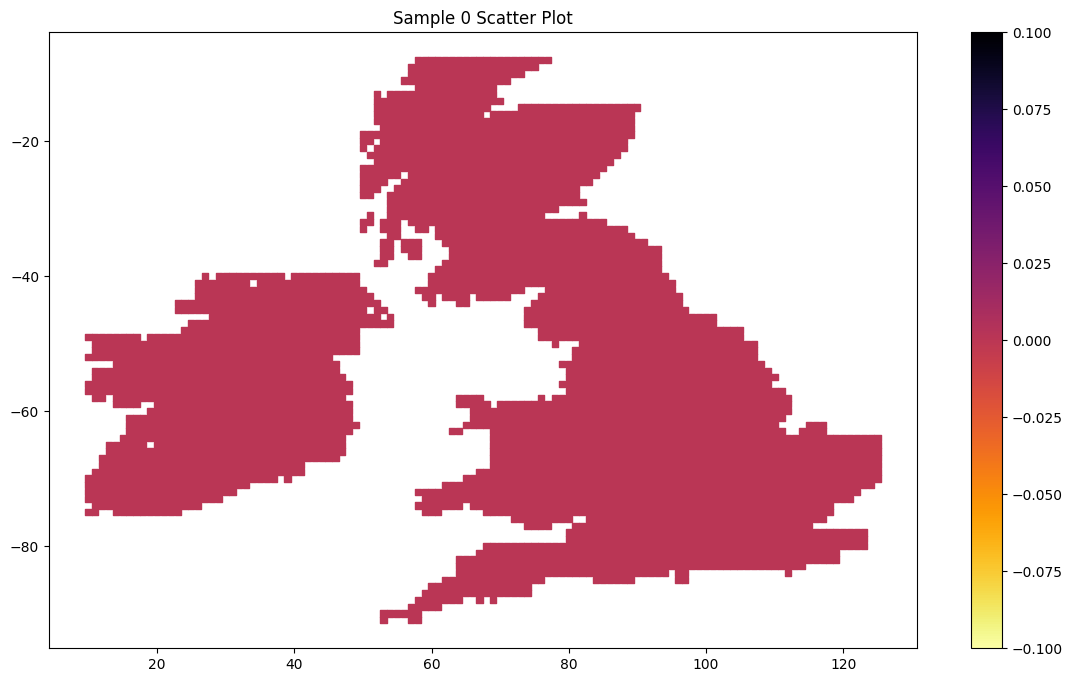

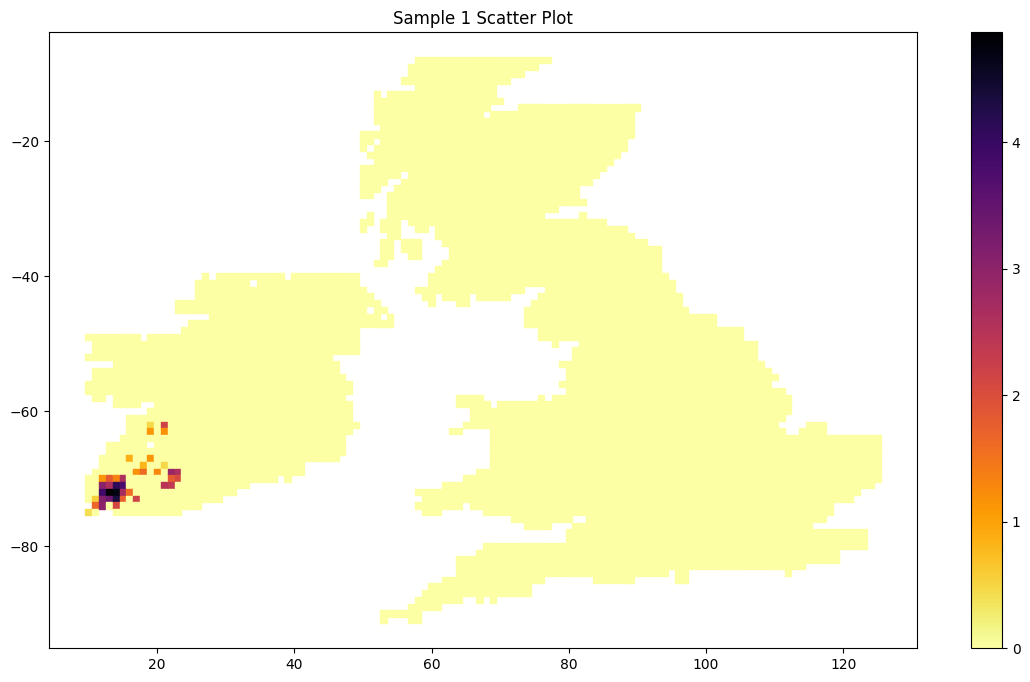

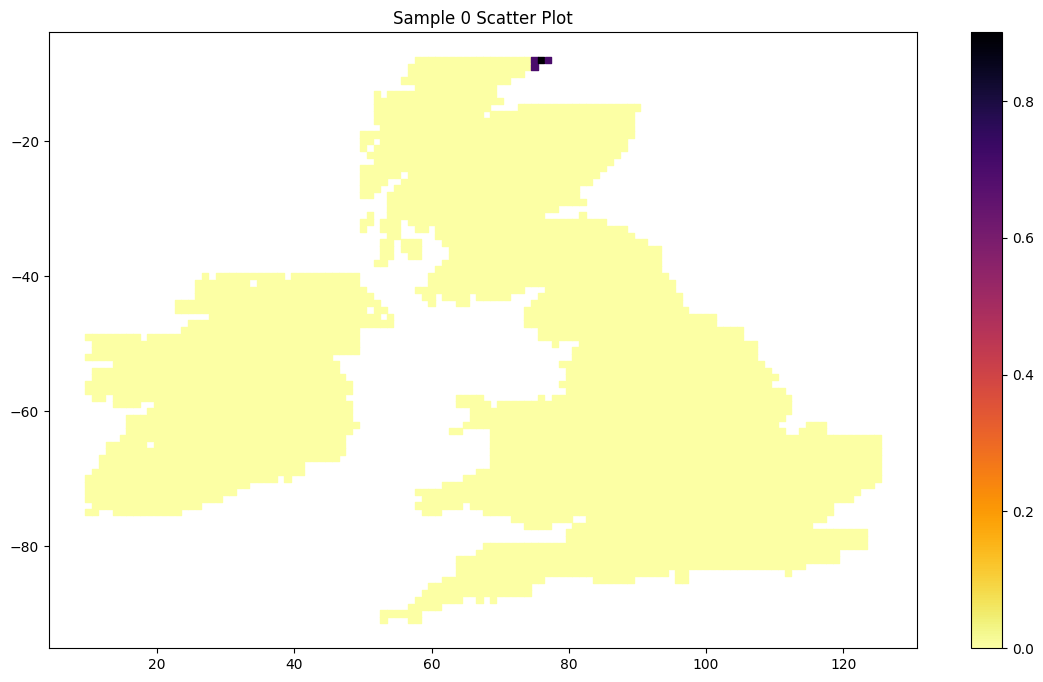

In [76]:
sims_a0,dist_mat_a0,cov_mat_a0 = sample_uncensored_copula(alpha=0,theta=34.8212,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None, return_dist_matrix=True, return_cov_matrix=True)
day_shown = day_subset_test[8]
plot_samples(tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),day_shown) for sim in range(2)]),GNM_landonly)
plot_samples(tt([GNM_landonly[l][3][day_shown] for l in range(len(GNM_landonly))]).unsqueeze(0),GNM_landonly)


# a=0.005 and theta=36.4930

In [ ]:
all_sims_a0_005_theta36_4930 = np.zeros((100,len(GNM_landonly[0][0]),4087), dtype=np.float16)

for day in tqdm(range(all_sims_a0_005_theta36_4930.shape[1])):
    sims = sample_uncensored_copula(alpha=0.005,theta=36.4930,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None)[0]
    rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
    all_sims_a0_005_theta36_4930[:,day,:] = rain_sims

#np.save('all_sims_a0_005_theta36_4930.npy', all_sims_a0_005_theta36_4930)

100%|██████████| 7301/7301 [2:38:26<00:00,  1.30s/it]  


# a=0.03 and theta=63.6832

In [ ]:
all_sims_a0_03_theta63_6832 = np.zeros((100,len(GNM_landonly[0][0]),4087), dtype=np.float16)

for day in tqdm(range(all_sims_a0_03_theta63_6832.shape[1])):
    sims = sample_uncensored_copula(alpha=0.03,theta=63.6832,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None)[0]
    rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
    all_sims_a0_03_theta63_6832[:,day,:] = rain_sims

#np.save('all_sims_a0_03_theta63_6832.npy', all_sims_a0_03_theta63_6832)

100%|██████████| 7301/7301 [2:39:19<00:00,  1.31s/it]  


# a=0.07226 and theta=83.2354

In [ ]:
all_sims_a0_07226_theta83_2354 = np.zeros((100,len(GNM_landonly[0][0]),4087), dtype=np.float16)

for day in tqdm(range(all_sims_a0_07226_theta83_2354.shape[1])):
    sims = sample_uncensored_copula(alpha=0.07226,theta=83.2354,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None)[0]
    rain_sims = tt([GNM_z_to_y(sims[sim,:],day) for sim in range(100)], dtype=torch.float16).numpy()
    all_sims_a0_07226_theta83_2354[:,day,:] = rain_sims

#np.save('all_sims_a0_07226_theta83_2354.npy', all_sims_a0_07226_theta83_2354)

100%|██████████| 7301/7301 [2:31:04<00:00,  1.24s/it]  


## RMSE and MAE

In [65]:
all_sims_a0_theta34_8212.shape[1]

7301

In [78]:
RMSE = np.zeros(all_sims_a0_theta34_8212.shape[2])

#3 mins
for day in tqdm(range(all_sims_a0_theta34_8212.shape[1])):
    RMSE = RMSE + np.power(
        np.subtract(
            [GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],
            all_sims_a0_theta34_8212[:,day,:].mean(0)
            ),2)

RMSE = np.sqrt(RMSE/all_sims_a0_theta34_8212.shape[1])
np.save('RMSE_JGNM.npy',RMSE)

100%|██████████| 7301/7301 [01:11<00:00, 102.66it/s]


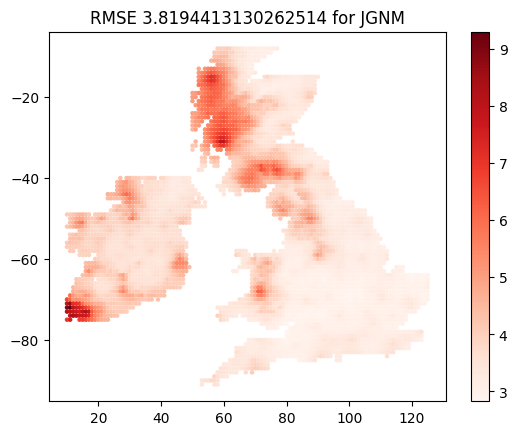

3.8194413130262514


In [84]:
plt.scatter([GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],
[-GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],
c=RMSE,s=5,cmap='Reds')
plt.colorbar()
plt.title(f'RMSE {RMSE.mean()} for JGNM')
plt.show()
print(RMSE.mean())

In [91]:
MAE = np.zeros(all_sims_a0_theta34_8212.shape[2])

#3 mins
for day in tqdm(range(all_sims_a0_theta34_8212.shape[1])):
    MAE = MAE + np.abs(
        np.subtract(
            [GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],
            np.median(all_sims_a0_theta34_8212[:,day,:],0)
            ))

MAE = MAE/all_sims_a0_theta34_8212.shape[1]
np.save('MAE_JGNM.npy',MAE)

100%|██████████| 7301/7301 [00:56<00:00, 129.69it/s]


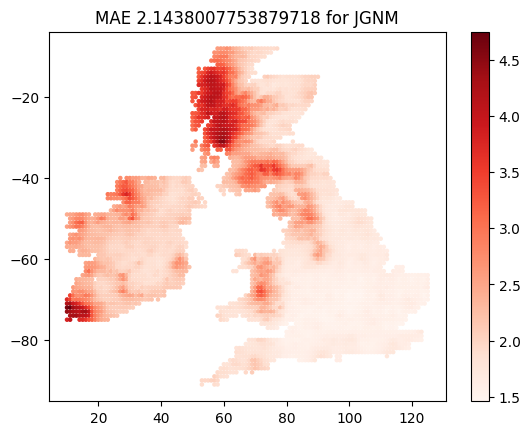

2.1438007753879718


In [93]:
plt.scatter([GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],
[-GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],
c=MAE,s=5,cmap='Reds')
plt.colorbar()
plt.title(f'MAE {MAE.mean()} for JGNM')
plt.show()
print(MAE.mean())

## CRPS

In [26]:
def estimate_CRPS_score_fast(obs,sims):
    '''
    obs: one vector of observations [y_1, y_2, ... y_n], ideally n corresponds to locations.
    sims: m vectors of simulations, each vector has length n. [[x_11, x_21,..., x_n1] ,..., [x_1m, x_2m,..., x_nm] ]

    returns: a vector [s1, ... , sn] of one score per location. this is for a single day, so would still need to average across days.
    '''
    m = len(sims)

    obs= np.array(obs)
    sims=np.array(sims)

    # |X-x|    
    diff_X_x = np.mean(
        np.abs(
            np.tile(obs,(m,1)) - sims
            ),
        axis=0)

    #|X-X'|
    diff_X_tilde_X = np.sum(
        np.abs(
            np.tile(sims,(m,1))-
            np.repeat(sims,m,axis=0)
            )
            ,axis=0
        )/(m*m-1)

    return 2*diff_X_x - diff_X_tilde_X 


In [33]:
all_sims_a0_theta34_8212.shape

(100, 7301, 4087)

In [ ]:
SR_crps = np.zeros((all_sims_a0_theta34_8212.shape[1],4087))
for day in tqdm(range(all_sims_a0_theta34_8212.shape[1])):
    SR_crps[day] = estimate_CRPS_score_fast([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))],all_sims_a0_theta34_8212[:,day,:])

SR_crps = SR_crps/len(GNM_output['target_rain'])
np.save('SR_JGNM_crps.npy',SR_crps)

100%|██████████| 7301/7301 [1:39:33<00:00,  1.22it/s]
C:\Users\u1819911\AppData\Local\Temp\ipykernel_8764\2642650322.py:5: RuntimeWarning: divide by zero encountered in divide
  SR_crps = SR_crps/len(GNM_output['target_rain'])


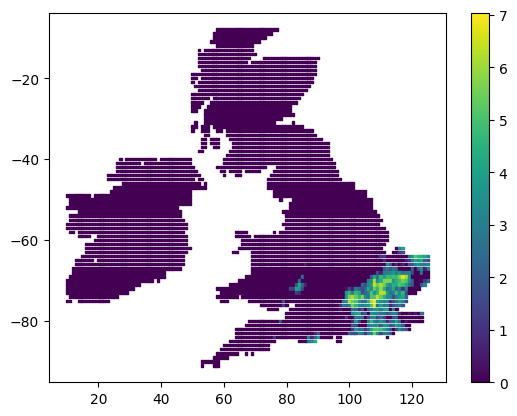

In [48]:
plt.scatter([GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],
[-GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],
c=all_sims_a0_theta34_8212[10,day,:],s=3,marker='s')
plt.colorbar()

## Energy score

100%|██████████| 7301/7301 [01:27<00:00, 83.03it/s] 


15.725303


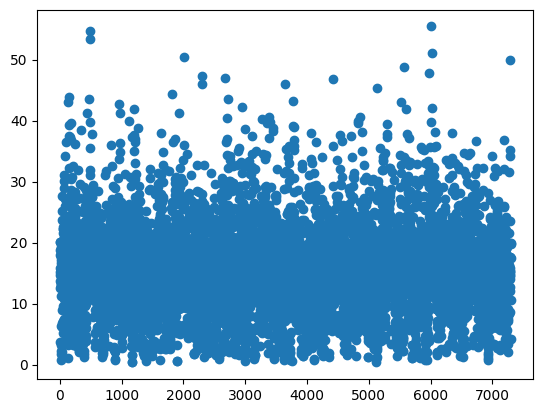

In [25]:
SR_energy = []
for day in tqdm(range(len(GNM_landonly[0][0]))):
    SR_energy.append(Energy_Score(0.5,tt([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]).unsqueeze(0),tt(all_sims_a0_theta34_8212[:,day,:]).to(dtype=torch.float32)))

plt.scatter(range(len(SR_energy)),SR_energy)
print(np.mean(SR_energy))
np.save('SR_energy_a0_theta34_8212.npy', SR_energy)

100%|██████████| 7301/7301 [01:18<00:00, 93.25it/s] 


15.739441


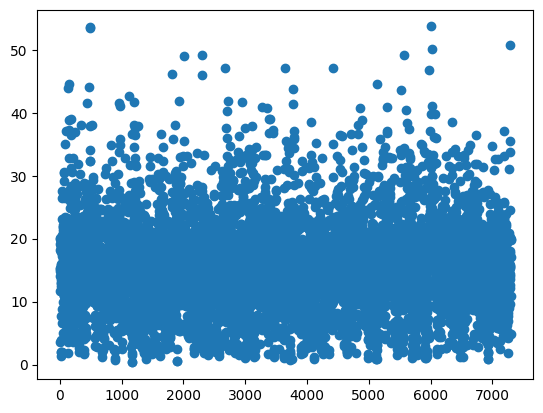

In [26]:
SR_energy = []
for day in tqdm(range(len(GNM_landonly[0][0]))):
    SR_energy.append(Energy_Score(0.5,tt([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]).unsqueeze(0),tt(all_sims_a0_005_theta36_4930[:,day,:]).to(dtype=torch.float32)))

plt.scatter(range(len(SR_energy)),SR_energy)
print(np.mean(SR_energy))
np.save('SR_energy_a0_005_theta36_4930.npy', SR_energy)

100%|██████████| 7301/7301 [01:15<00:00, 97.06it/s] 


15.738297


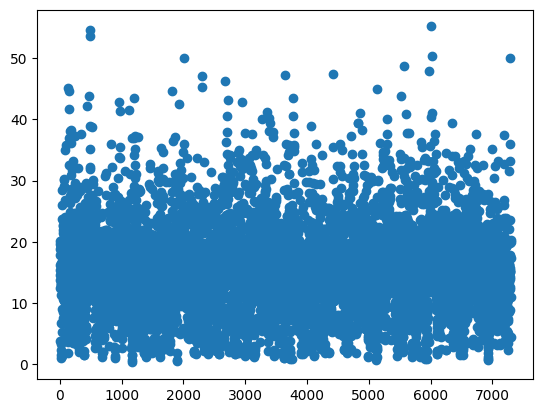

In [27]:
SR_energy = []
for day in tqdm(range(len(GNM_landonly[0][0]))):
    SR_energy.append(Energy_Score(0.5,tt([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]).unsqueeze(0),tt(all_sims_a0_03_theta63_6832[:,day,:]).to(dtype=torch.float32)))

plt.scatter(range(len(SR_energy)),SR_energy)
print(np.mean(SR_energy))
np.save('SR_energy_a0_03_theta63_6832.npy', SR_energy)

100%|██████████| 7301/7301 [01:52<00:00, 64.94it/s] 


15.785199


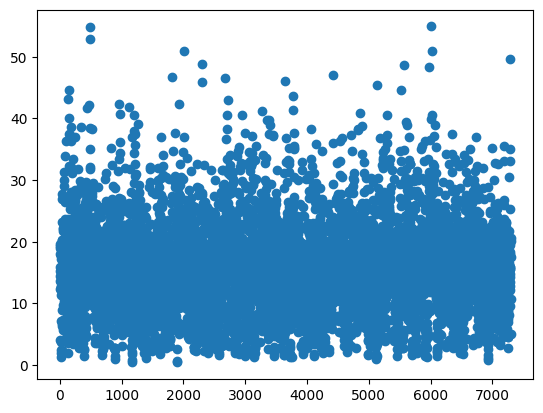

In [28]:
SR_energy = []
for day in tqdm(range(len(GNM_landonly[0][0]))):
    SR_energy.append(Energy_Score(0.5,tt([GNM_landonly[l][3][day] for l in range(len(GNM_landonly))]).unsqueeze(0),tt(all_sims_a0_07226_theta83_2354[:,day,:]).to(dtype=torch.float32)))

plt.scatter(range(len(SR_energy)),SR_energy)
print(np.mean(SR_energy))
np.save('SR_energy_a0_07226_theta83_2354.npy', SR_energy)

## Variogram

In [10]:
def Variogram_single_day(observations_y,simulations_Y,distance_matrix):

    n = len(observations_y)
    m = len(simulations_Y)
    y = np.array(observations_y)
    Y = np.array(simulations_Y)

    # inverse distance matrix, for weights w_ij:
    w_ij = np.nan_to_num( 1/distance_matrix, copy=False, nan=0, posinf=0, neginf=0)

    # |y_i - y_j| first part of Variogram
    diff_y_y = euclidean_distances(y.reshape(-1,1))

    # |Y_k,i - Y_k,j| second part of Variogram
    diff_Y_Y = np.mean(np.abs(np.tile(Y,n).reshape(m,n*n)-np.repeat(Y,n).reshape(m,n*n)),axis=0).reshape(n,n)

    Variogram = np.multiply(
        w_ij,
        np.power(
            diff_y_y - diff_Y_Y
        ,2)
    )

    return np.sum(Variogram)

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))


In [13]:
len(GNM_landonly[0][0])

7301

In [21]:
Variogram_diagnostic = []
for d in tqdm(range(len(GNM_landonly[0][0]))):
    Variogram_diagnostic.append(Variogram_single_day(tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]),
                     tt(all_sims_a0_theta34_8212[:10,d,:]),
                     dist_mat))

np.save('SR_Variogram_jgnm_testset.npy', Variogram_diagnostic)

  0%|          | 0/7301 [00:00<?, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_8764\2246193038.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(observations_y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_8764\2246193038.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Y = np.array(simulations_Y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_8764\2246193038.py:9: RuntimeWarning: divide by zero encountered in divide
  w_ij = np.nan_to_num( 1/dis

KeyboardInterrupt: 

In [25]:
np.array(Variogram_diagnostic).shape

(983,)

# Empirical covariance vs distance

In [1]:
def compute_average_corr_per_dist(all_corr, dist_mat):
    ''' 
    Compute the average correlation per distance, following dist_mat as the distance mask.
    '''
    unique_distances = np.sort(np.unique(dist_mat))
    average_corr_per_dist = []
    std_corr_per_dist = []
    for d in tqdm(unique_distances):
        if d == 0:
            continue
        mask = (dist_mat == d)
        average_corr_per_dist.append(np.mean(all_corr[mask]))
        std_corr_per_dist.append(np.std(all_corr[mask]))
    return average_corr_per_dist, std_corr_per_dist

# 6 mins
sim_version = 2

corr_per_dist_sims_a0, std_per_dist_sims_a0 = compute_average_corr_per_dist(np.cov(np.concatenate(all_sims_a0_theta34_8212[:10]).T), dist_mat)
corr_per_dist_sims_a0_005, std_per_dist_sims_a0_005 = compute_average_corr_per_dist(np.cov(np.concatenate(all_sims_a0_005_theta36_4930[:10]).T), dist_mat)
corr_per_dist_sims_a0_03, std_per_dist_sims_a0_03 = compute_average_corr_per_dist(np.cov(np.concatenate(all_sims_a0_03_theta63_6832[:10]).T), dist_mat)
corr_per_dist_sims_a0_07226, std_per_dist_sims_a0_07226 = compute_average_corr_per_dist(np.cov(np.concatenate(all_sims_a0_07226_theta83_2354[:10]).T), dist_mat)
corr_per_dist_obs, std_per_dist_obs = compute_average_corr_per_dist(np.cov(tt([GNM_landonly[l][3][:len(GNM_landonly[0][3])] for l in range(len(GNM_landonly))])), dist_mat)

NameError: name 'np' is not defined

In [ ]:
'''np.save('corr_per_dist_sims_a0.npy', corr_per_dist_sims_a0)
np.save('std_per_dist_sims_a0.npy', std_per_dist_sims_a0)
np.save('corr_per_dist_sims_a0_005.npy', corr_per_dist_sims_a0_005)
np.save('std_per_dist_sims_a0_005.npy', std_per_dist_sims_a0_005)
np.save('corr_per_dist_sims_a0_03.npy', corr_per_dist_sims_a0_03)
np.save('std_per_dist_sims_a0_03.npy', std_per_dist_sims_a0_03)
np.save('corr_per_dist_sims_a0_07226.npy', corr_per_dist_sims_a0_07226)
np.save('std_per_dist_sims_a0_07226.npy', std_per_dist_sims_a0_07226)
np.save('corr_per_dist_obs.npy', corr_per_dist_obs)
np.save('std_per_dist_obs.npy', std_per_dist_obs)
'''

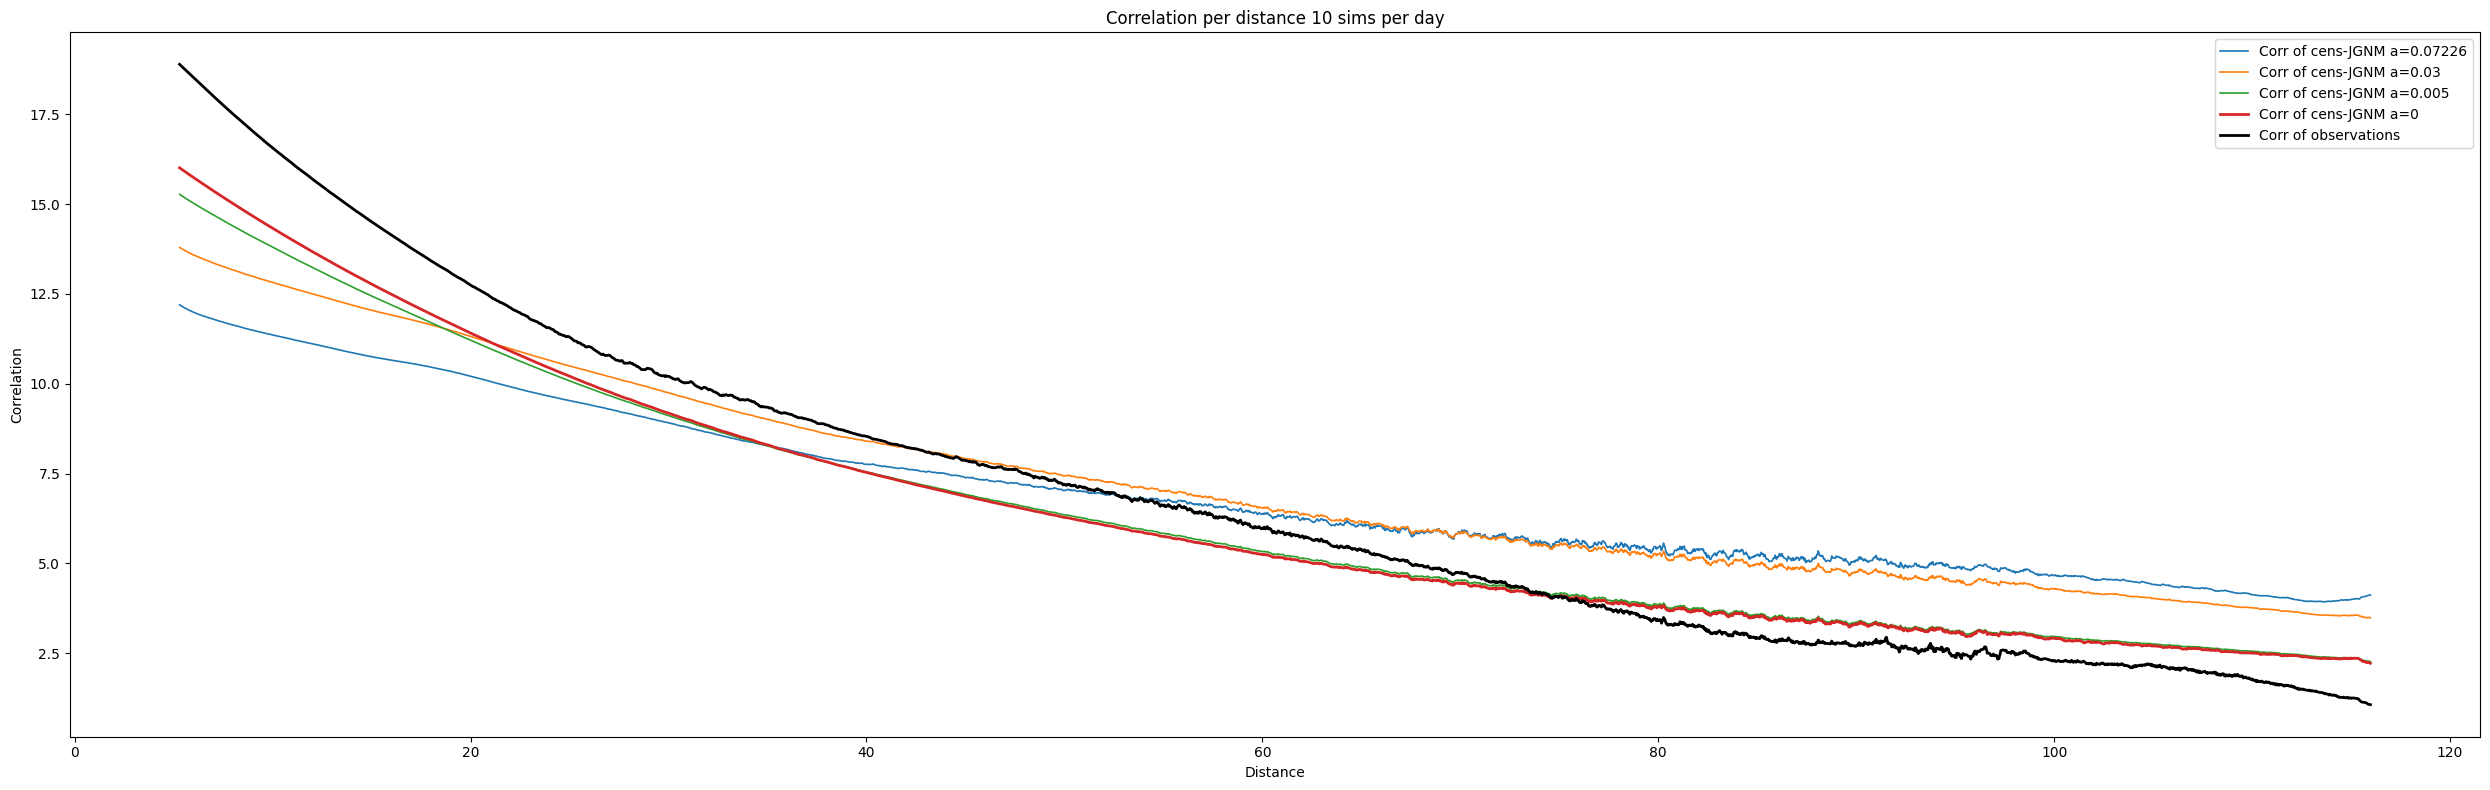

In [209]:
plt.figure(figsize=(25,8))

# Compute rolling average of correlation values
def rolling_average(data, window_size=30):
    return [np.mean(data[1 + k:window_size + k]) for k in range(0, len(data) - window_size)]

x_dists = rolling_average((np.sort(np.unique(dist_mat)))[1:])

lw = 1.2

plt.plot(x_dists,rolling_average(corr_per_dist_sims_a0_07226),label='Corr of cens-JGNM a=0.07226',linewidth=lw)

plt.plot(x_dists,rolling_average(corr_per_dist_sims_a0_03),label='Corr of cens-JGNM a=0.03',linewidth=lw)

plt.plot(x_dists,rolling_average(corr_per_dist_sims_a0_005),label='Corr of cens-JGNM a=0.005',linewidth=lw)

plt.plot(x_dists,rolling_average(corr_per_dist_sims_a0),label='Corr of cens-JGNM a=0',linewidth=2)

plt.plot(x_dists,rolling_average(corr_per_dist_obs), label='Corr of observations',c='black',linewidth=2)

plt.xlabel('Distance')
plt.ylabel('Correlation')
plt.legend()
plt.title('Correlation per distance 10 sims per day')
plt.tight_layout()
plt.show()

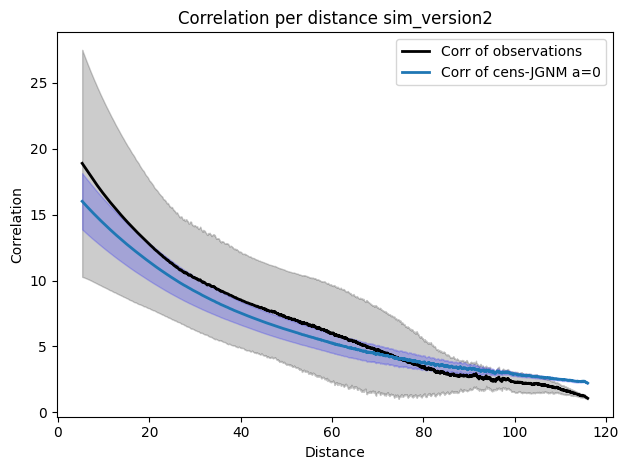

In [208]:
# Plot with confidence bands
corr_per_dist_sims_a0 = np.array(corr_per_dist_sims_a0)
std_per_dist_sims_a0 = np.array(std_per_dist_sims_a0)
corr_per_dist_sims_a0_005 = np.array(corr_per_dist_sims_a0_005)
std_per_dist_sims_a0_005 = np.array(std_per_dist_sims_a0_005)
corr_per_dist_sims_a0_03 = np.array(corr_per_dist_sims_a0_03)
std_per_dist_sims_a0_03 = np.array(std_per_dist_sims_a0_03)
corr_per_dist_sims_a0_07226 = np.array(corr_per_dist_sims_a0_07226)
std_per_dist_sims_a0_07226 = np.array(std_per_dist_sims_a0_07226)
corr_per_dist_obs = np.array(corr_per_dist_obs)
std_per_dist_obs = np.array(std_per_dist_obs)

'''
plt.plot(x_dists, corr_per_dist_sims_a0_07226, label='Corr of cens-JGNM a=0.07226', linewidth=lw)
plt.fill_between(x_dists, corr_per_dist_sims_a0_07226 - std_per_dist_sims_a0_07226, corr_per_dist_sims_a0_07226 + std_per_dist_sims_a0_07226, alpha=0.2)

plt.plot(x_dists, corr_per_dist_sims_a0_03, label='Corr of cens-JGNM a=0.03', linewidth=lw)
plt.fill_between(x_dists, corr_per_dist_sims_a0_03 - std_per_dist_sims_a0_03, corr_per_dist_sims_a0_03 + std_per_dist_sims_a0_03, alpha=0.2)

plt.plot(x_dists, corr_per_dist_sims_a0_005, label='Corr of cens-JGNM a=0.005', linewidth=lw)
plt.fill_between(x_dists, corr_per_dist_sims_a0_005 - std_per_dist_sims_a0_005, corr_per_dist_sims_a0_005 + std_per_dist_sims_a0_005, alpha=0.2)
'''

plt.plot(x_dists, rolling_average(corr_per_dist_obs), label='Corr of observations', c='black', linewidth=2)
plt.fill_between(x_dists, rolling_average(corr_per_dist_obs - std_per_dist_obs), rolling_average(corr_per_dist_obs + std_per_dist_obs), alpha=0.2, color='black')

plt.plot(x_dists, rolling_average(corr_per_dist_sims_a0), label='Corr of cens-JGNM a=0', linewidth=2)
plt.fill_between(x_dists, rolling_average(corr_per_dist_sims_a0 - std_per_dist_sims_a0), rolling_average(corr_per_dist_sims_a0 + std_per_dist_sims_a0), alpha=0.2, color='blue')


plt.xlabel('Distance')
plt.ylabel('Correlation')
plt.title('Correlation per distance sim_version2')
plt.legend()
plt.tight_layout()
plt.show()

# Maps with pooled crps over time and space - for floods

100


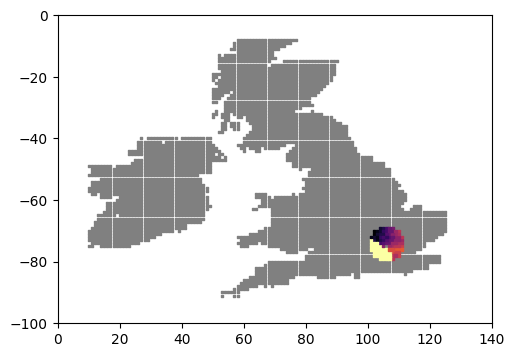

In [325]:
def generate_subsample_locs(locs_nb, random_center = 3532):
    locs=[]
    while len(locs)<locs_nb:
        #random_center = np.random.choice(range(len(GNM_landonly))) 
 
        locs = np.where([math.dist(GNM_landonly[k][5],GNM_landonly[random_center ][5])<(np.sqrt(locs_nb/np.pi)+0.1) for k in range(len(GNM_landonly))])[0]
    return np.random.choice(locs,size=locs_nb,replace=False)    

fig = plt.gcf() 
fig.set_size_inches(5.6,4)
locs = generate_subsample_locs(locs_nb=100)
print(len(locs))

plt.scatter([GNM_landonly[l][5][1] for l in range(len(GNM_landonly))],
[-GNM_landonly[l][5][0] for l in range(len(GNM_landonly))],
c='grey',s=3,marker='s')

plt.scatter([GNM_landonly[loc][5][1] for loc in locs],
[-GNM_landonly[loc][5][0] for loc in locs],
c=[GNM_landonly[loc][3][300] for loc in locs],
cmap='inferno_r',s=3,marker='s')


plt.xlim(0,140)
plt.ylim(-100,0)
plt.show()

In [ ]:
# Computing the aggregate rainfall in area for a sequence of x days. Each such sequence of aggregate values is one sample from the spatio-temporal distribution over aggregate rain. 
# Compute CRPS for aggregate on one day - per day. Here just do CRPS(avg,[avg(sim_i) for i])
def estimate_CRPS_score_fast(obs,sims):
    '''
    obs: one vector of observations [y_1, y_2, ... y_n], ideally n corresponds to locations.
    sims: m vectors of simulations, each vector has length n. [[x_11, x_21,..., x_n1] ,..., [x_1m, x_2m,..., x_nm] ]

    returns: a vector [s1, ... , sn] of one score per location. this is for a single day, so would still need to average across days.
    '''
    m = len(sims)

    obs= np.array(obs)
    sims=np.array(sims)

    # |X-x|    
    diff_X_x = np.mean(
        np.abs(
            np.tile(obs,(m,1)) - sims
            ),
        axis=0)

    #|X-X'|
    diff_X_tilde_X = np.sum(
        np.abs(
            np.tile(sims,(m,1))-
            np.repeat(sims,m,axis=0)
            )
            ,axis=0
        )/(m*m-1)

    return 2*diff_X_x - diff_X_tilde_X 

CRPS_spatial_rain_total_day_sims_a0 = estimate_CRPS_score_fast(np.array([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(len(GNM_landonly[0][3]))]),np.mean(all_sims_a0_theta34_8212[:,:len(GNM_landonly[0][3]),locs],2))
CRPS_spatial_rain_total_day_target = np.array([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(len(GNM_landonly[0][3]))])[np.isfinite(CRPS_spatial_rain_total_day_sims_a0)]
CRPS_spatial_rain_total_day_sims_a0 = CRPS_spatial_rain_total_day_sims_a0[np.isfinite(CRPS_spatial_rain_total_day_sims_a0)]

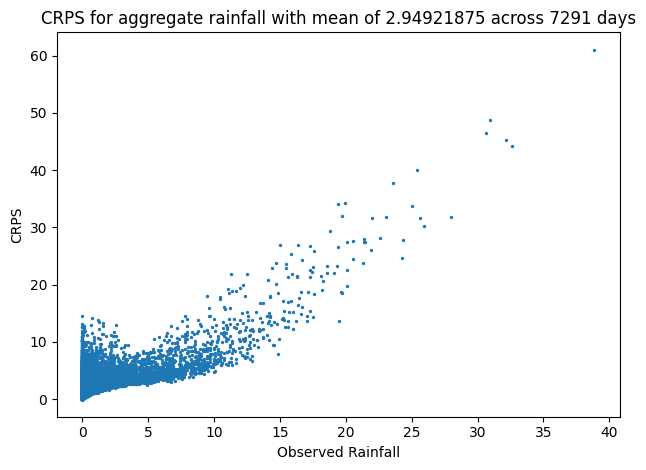

In [330]:
plt.scatter(CRPS_spatial_rain_total_day_target,CRPS_spatial_rain_total_day_sims_a0,s=2)
plt.xlabel('Observed Rainfall')
plt.ylabel('CRPS')
plt.title(f'CRPS for aggregate rainfall with mean of {np.mean(CRPS_spatial_rain_total_day_sims_a0)} across {len(CRPS_spatial_rain_total_day_sims_a0)} days')
plt.tight_layout()
plt.show()

In [379]:
# Compute Energy on sequences of x days. 

Energy_spatiotemporal_2_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-2)):
    Energy_spatiotemporal_2_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+2)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+2,locs],2)).to(dtype=torch.float32),
        ))

Energy_spatiotemporal_3_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-3)):
    Energy_spatiotemporal_3_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+3)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+3,locs],2)).to(dtype=torch.float32),
        ))            
    
Energy_spatiotemporal_4_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-4)):
    Energy_spatiotemporal_4_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+4)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+4,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_5_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-5)):
    Energy_spatiotemporal_5_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+5)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+5,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_6_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-6)):
    Energy_spatiotemporal_6_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+6)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+6,locs],2)).to(dtype=torch.float32),
        ))
    
Energy_spatiotemporal_7_rain_total_sims_a0 = []
for day_window_index in tqdm(range(len(GNM_landonly[0][3])-7)):
    Energy_spatiotemporal_7_rain_total_sims_a0.append(
        Energy_Score(1,
            tt([np.mean([GNM_landonly[l][3][day] for l in locs]) for day in range(day_window_index,day_window_index+7)]).unsqueeze(0),
            tt(np.mean(all_sims_a0_theta34_8212[:,day_window_index:day_window_index+7,locs],2)).to(dtype=torch.float32),
        ))
                                                 

  0%|          | 0/7299 [00:00<?, ?it/s]

100%|██████████| 7294/7294 [00:09<00:00, 810.38it/s]


In [381]:
CRPS_spatial_rain_total_day_sims_a0.shape

(7291,)

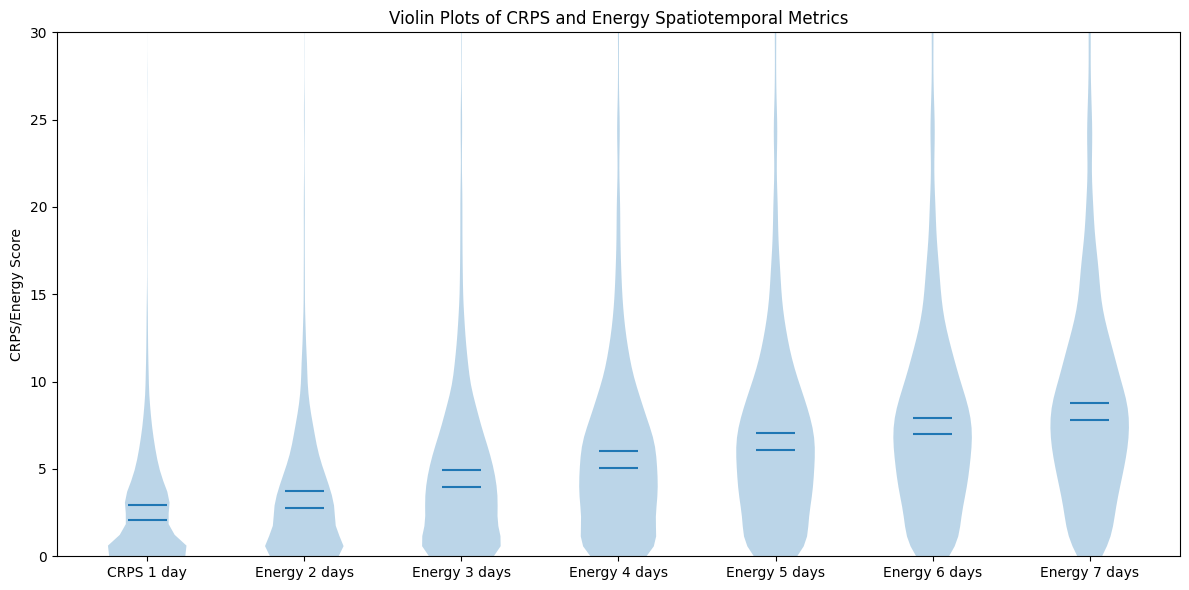

In [397]:
# Create a common plot with shared y-axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the violin plots
ax.violinplot([CRPS_spatial_rain_total_day_sims_a0,
               Energy_spatiotemporal_2_rain_total_sims_a0,
               Energy_spatiotemporal_3_rain_total_sims_a0,
               Energy_spatiotemporal_4_rain_total_sims_a0,
               Energy_spatiotemporal_5_rain_total_sims_a0,
               Energy_spatiotemporal_6_rain_total_sims_a0,
               Energy_spatiotemporal_7_rain_total_sims_a0], showmeans=True, showmedians=True,showextrema=False)

# Set the x-ticks and labels
ax.set_xticks(range(1, 8))
ax.set_xticklabels(['CRPS 1 day'] + [f'Energy {i} days' for i in range(2, 8)])

# Set the labels and title
ax.set_ylabel('CRPS/Energy Score')
ax.set_title('Violin Plots of CRPS and Energy Spatiotemporal Metrics')

# Show the plot
plt.ylim(0, 30)
plt.tight_layout()
plt.show()